In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Dec 2023

@author: Rodrigo Pena
"""
!pip install brian2
from brian2 import *
seed(111)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.0 MB/s eta 0:00:00


In [2]:
def fixed_indegree(indegree,n_post_pop,n_pre_pop):
    np.random.seed(10)
    presyn_indices = np.zeros([n_post_pop*indegree])
    postsyn_indices = np.zeros([n_post_pop*indegree])
    counter = 0

    for post in range(n_post_pop):
        x = np.arange(0, n_pre_pop)
        y = np.random.permutation(x)
        for i in range(indegree):
            presyn_indices[counter] = y[i]
            postsyn_indices[counter] = post
            counter += 1
    presyn_indices = presyn_indices.astype(int)
    postsyn_indices = postsyn_indices.astype(int)
    return presyn_indices, postsyn_indices

In [ ]:
def simulation(tf,orien,pope_pref1 = 10, pope_pref2 = 10, pope_pref3 = 10, pope_pref4 = 10,
               popi_pref1 = 90, popi_pref2 = 10, popi_pref3 = 10, popi_pref4 = 10, pl=0,
               size_orientation=30):

    seed(10)
    #net parameters
    NE = 4000
    gamma = 0.2
    NI = int(gamma*NE)
    CE = int(NE*0.2)
    CI = int(gamma*CE)
    tau = 20*ms #time constant
    tref = 2*ms
    vth = 20
    vr = 0
    J = 0.1
    g = 8
    D = 3*ms
    #sigma_noise = 0.1 #standard deviation of noise

    eqs = '''
    dv/dt = (-v + I + sigma_noise * xi * sqrt(dt)) / tau : 1 (unless refractory)
    I = current_amplitude * cos((pi/180)*(stimulus_orientation - preferred_orientation)) * exp(-0.5 * ((stimulus_orientation - preferred_orientation) / orientation_tuning_width)**2) : 1
    preferred_orientation : 1
    current_amplitude : 1 (shared)
    stimulus_orientation : 1 (shared)
    orientation_tuning_width : 1 (shared)
    sigma_noise : 1  # Noise standard deviation (dimensionless)


   #eqs='''
    #neurons

    neurons = NeuronGroup(NE+NI,eqs,method='euler',dt=0.01*ms,threshold='v>=vth',reset='v=vr',refractory=tref)
    neurons.v = 'rand()*(vth-vr) + vr'
    pop_alle = neurons[:NE]
    pop_e1 = neurons[:1000] #[:NE]
    pop_e2 = neurons[1000:2000]
    pop_e3 = neurons[2000:3000]
    pop_e4 = neurons[3000:NE]
    pop_alli = neurons[NE:(NE+NI)]
    pop_i1 = neurons[4000:4200]
    pop_i2 = neurons[4200:4400]
    pop_i3 = neurons[4400:4600]
    pop_i4 = neurons[4600:]

    # # Set up orientation-selective current

    neurons[:1000].preferred_orientation = pope_pref1
    neurons[1000:2000].preferred_orientation = pope_pref2
    neurons[2000:3000].preferred_orientation = pope_pref3
    neurons[3000:NE].preferred_orientation = pope_pref4 # Preferred orientation in degrees

    neurons[4000:4200].preferred_orientation = popi_pref1
    neurons[4200:4400].preferred_orientation = popi_pref2
    neurons[4400:4600].preferred_orientation = popi_pref3
    neurons[4600:].preferred_orientation = popi_pref4
    #---
    #neurons[NE:(NE+NI)].preferred_orientation = popi_pref  # Preferred orientation in degrees
    neurons.stimulus_orientation = orien  # Stimulus orientation in degrees
    # Generate cosine-tuned current profile
    neurons.current_amplitude = 50
    neurons.orientation_tuning_width = size_orientation

    #Poisson
    P = PoissonInput(neurons, 'v', NE+NI, 1*Hz, weight=2*J)

    #E indexes
    presyn_indices,postsyn_indices=fixed_indegree(CE,(NE+NI),NE)
    con_e = Synapses(pop_alle, neurons, on_pre='v += J', delay=D,dt=0.01*ms)
    con_e.connect(i=presyn_indices,j=postsyn_indices)

    #I indexes
    presyn_indices,postsyn_indices=fixed_indegree(CI,(NE+NI),NI)
    con_i = Synapses(pop_alli, neurons, on_pre='v -= J*g', delay=D,dt=0.01*ms)
    con_i.connect(i=presyn_indices,j=postsyn_indices)


    ratemon = PopulationRateMonitor(neurons)
    spkmon = SpikeMonitor(neurons)

    net = Network(neurons, pop_alle, pop_alli, con_e, con_i, P, spkmon, ratemon)
    net.run(tf,'stdout')

    if(pl==1):

        subplot(2,1,1)
        plot(spkmon.t/ms,spkmon.i,'k.',markersize=0.5)
        # ylim(950,1000)
        xlim(1000,1800)

        subplot(2,1,2)
        plot(ratemon.t/ms, ratemon.rate/Hz)
        xlim(1000,1800)
        show()

    return spkmon, ratemon

### Percentages as Simulation Parameters

In [3]:
def simulation(tf, orien, pope_pref1=10, pope_pref2=10, pope_pref3=10, pope_pref4=10,
               popi_pref1=90, popi_pref2=10, popi_pref3=10, popi_pref4=10, pl=0,
               size_orientation=30, percent_e1=25, percent_e2=25, percent_e3=25, percent_e4=25,
               percent_i1=25, percent_i2=25, percent_i3=25, percent_i4=25):

    # Seed for reproducibility
    seed(10)

    # Net parameters
    NE = 4000
    gamma = 0.2
    NI = int(gamma * NE)
    CE = int(NE * 0.2)
    CI = int(gamma * CE)
    tau = 20 * ms  # time constant
    tref = 2 * ms
    vth = 20
    vr = 0
    J = 0.1
    g = 8
    D = 3 * ms

    # Equation definition
    eqs = '''
    dv/dt = (-v + I + sigma_noise * xi * sqrt(dt)) / tau : 1 (unless refractory)
    I = current_amplitude * cos((pi/180)*(stimulus_orientation - preferred_orientation)) * exp(-0.5 * ((stimulus_orientation - preferred_orientation) / orientation_tuning_width)**2) : 1
    preferred_orientation : 1
    current_amplitude : 1 (shared)
    stimulus_orientation : 1 (shared)
    orientation_tuning_width : 1 (shared)
    sigma_noise : 1  # Noise standard deviation (dimensionless)
    '''

    # Create neuron groups
    neurons = NeuronGroup(NE + NI, eqs, method='euler', dt=0.01 * ms, threshold='v >= vth', reset='v = vr', refractory=tref)
    neurons.v = 'rand() * (vth - vr) + vr'

    # Calculate population sizes based on given percentages
    pop_e_sizes = [int(NE * percent / 100) for percent in [percent_e1, percent_e2, percent_e3, percent_e4]]
    pop_i_sizes = [int(NI * percent / 100) for percent in [percent_i1, percent_i2, percent_i3, percent_i4]]

    # Set neuron population indices
    pop_e1 = neurons[:pop_e_sizes[0]]
    pop_e2 = neurons[pop_e_sizes[0]:pop_e_sizes[0] + pop_e_sizes[1]]
    pop_e3 = neurons[pop_e_sizes[0] + pop_e_sizes[1]:pop_e_sizes[0] + pop_e_sizes[1] + pop_e_sizes[2]]
    pop_e4 = neurons[pop_e_sizes[0] + pop_e_sizes[1] + pop_e_sizes[2]:NE]

    pop_i1 = neurons[NE:NE + pop_i_sizes[0]]
    pop_i2 = neurons[NE + pop_i_sizes[0]:NE + pop_i_sizes[0] + pop_i_sizes[1]]
    pop_i3 = neurons[NE + pop_i_sizes[0] + pop_i_sizes[1]:NE + pop_i_sizes[0] + pop_i_sizes[1] + pop_i_sizes[2]]
    pop_i4 = neurons[NE + pop_i_sizes[0] + pop_i_sizes[1] + pop_i_sizes[2]:]

    # Set preferred orientations
    pop_e1.preferred_orientation = pope_pref1
    pop_e2.preferred_orientation = pope_pref2
    pop_e3.preferred_orientation = pope_pref3
    pop_e4.preferred_orientation = pope_pref4

    pop_i1.preferred_orientation = popi_pref1
    pop_i2.preferred_orientation = popi_pref2
    pop_i3.preferred_orientation = popi_pref3
    pop_i4.preferred_orientation = popi_pref4

    # Set shared parameters
    neurons.stimulus_orientation = orien
    neurons.current_amplitude = 50
    neurons.orientation_tuning_width = size_orientation

    # Poisson input
    P = PoissonInput(neurons, 'v', NE + NI, 1 * Hz, weight=2 * J)

    # Create synapses with E and I populations
    presyn_indices, postsyn_indices = fixed_indegree(CE, (NE + NI), NE)
    con_e = Synapses(neurons[:NE], neurons, on_pre='v += J', delay=D, dt=0.01 * ms)
    con_e.connect(i=presyn_indices, j=postsyn_indices)

    presyn_indices, postsyn_indices = fixed_indegree(CI, (NE + NI), NI)
    con_i = Synapses(neurons[NE:], neurons, on_pre='v -= J * g', delay=D, dt=0.01 * ms)
    con_i.connect(i=presyn_indices, j=postsyn_indices)

    # Monitors
    ratemon = PopulationRateMonitor(neurons)
    spkmon = SpikeMonitor(neurons)

    # Create and run the network
    net = Network(neurons, con_e, con_i, P, spkmon, ratemon)
    net.run(tf, 'stdout')

    # Plot results if requested
    if pl == 1:
        subplot(2, 1, 1)
        plot(spkmon.t / ms, spkmon.i, 'k.', markersize=0.5)
        xlim(1000, 1800)

        subplot(2, 1, 2)
        plot(ratemon.t / ms, ratemon.rate / Hz)
        xlim(1000, 1800)
        show()

    return spkmon, ratemon


In [6]:
trial = 1
rr = np.arange(1,180,22.5)
individual_rates = np.zeros((len(rr),4799))
count=0

seed(10)
for k in range(trial):
  mfr = [] #mean firing rate
  tf=200*ms
  for i in rr:
   # spks,rate = simulation(tf=tf,orien=150,pope_pref1=150,pope_pref2=30,pope_pref3=120,pope_pref4=30,
    #                                       popi_pref1=30,popi_pref2=120,popi_pref3=0,popi_pref4=60,pl=0,size_orientation=i,
     #                                      percent_e1=23.75, percent_e2=10, percent_e3=42.5, percent_e4=23.75,
      #                                     percent_i1=23.75, percent_i2=10, percent_i3=42.5, percent_i4=23.75)

    spks,rate = simulation(tf=tf,orien=120,pope_pref1=120,pope_pref2=0,pope_pref3=90,pope_pref4=0,
                                           popi_pref1=0,popi_pref2=90,popi_pref3=150,popi_pref4=30,pl=0,size_orientation=i,
                                           percent_e1=2.5, percent_e2=2.5, percent_e3=47.5, percent_e4=47.5,
                                           percent_i1=2.5, percent_i2=2.5, percent_i3=47.5, percent_i4=47.5)

    mfr.append(mean(spks.count)/tf)
    a = spks.t/ms
    b = spks.i
    for k in range(np.max(b)):
      aux = a[where(b==k)[0]]
      individual_rates[count,k] = len(aux)/1.0
    count = count + 1

Starting simulation at t=0. s for a duration of 200. ms
110.52 ms (55%) simulated in 10s, estimated 8s remaining.


WARNING    neurongroup's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]


200. ms (100%) simulated in 17s
Starting simulation at t=0. s for a duration of 200. ms
180.34 ms (90%) simulated in 10s, estimated 1s remaining.
200. ms (100%) simulated in 11s
Starting simulation at t=0. s for a duration of 200. ms
191.81 ms (95%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
161.32 ms (80%) simulated in 10s, estimated 2s remaining.
200. ms (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 200. ms
193.68 ms (96%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
158.64 ms (79%) simulated in 10s, estimated 3s remaining.
200. ms (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 200. ms
192.43 ms (96%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
191.39 ms (95%) simulated in 1

In [ ]:
individual_rates

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [12., 17., 15., ...,  1.,  0.,  0.],
       [10., 12., 12., ...,  0.,  0.,  0.],
       ...,
       [ 9., 11.,  9., ...,  0.,  0.,  0.],
       [ 8., 10.,  9., ...,  0.,  0.,  0.],
       [ 9.,  9., 11., ...,  1.,  0.,  0.]])

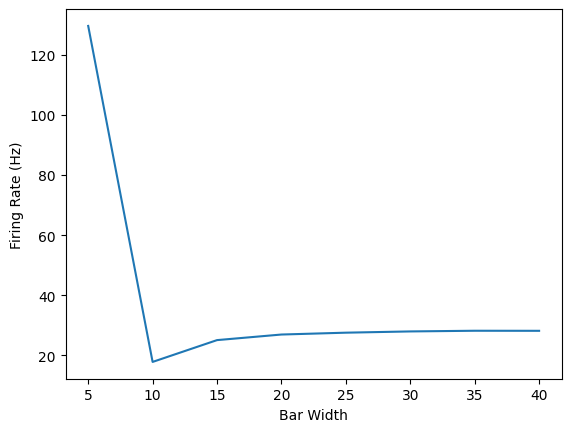

In [7]:
rr = np.linspace(1,180,8)  # Create 8 values between 1 and 180

# Normalize the x-values (size_orientation) from (1, 180) to (5, 40)
x_min, x_max = 1, 180
y_min, y_max = 5, 40
normalized_rr = y_min + ((rr - x_min) * (y_max - y_min)) / (x_max - x_min)

# Plotting with normalized x-values
plt.plot(normalized_rr, mfr, '-')
plt.xticks(np.arange(5, 45, 5))  # Updated ticks for the new x-range (5, 40, 5)
plt.xlabel("Bar Width")
plt.ylabel("Firing Rate (Hz)")
plt.show()

In [8]:
# Find highest response in each neuron and the size_orientation that produced it
highest_responses = []
corresponding_sizes = []

for neuron in range(individual_rates.shape[1]):  # Loop over each neuron (columns)
    max_response = max(individual_rates[:, neuron])  # Find max response for this neuron
    max_response_idx = individual_rates[:, neuron].argmax()  # Get index of the max response
    corresponding_size = normalized_rr[max_response_idx]  # Get the size that produced the max response

    highest_responses.append(max_response)
    corresponding_sizes.append(corresponding_size)

In [9]:
print(highest_responses)
print(corresponding_sizes)

[17.0, 18.0, 17.0, 18.0, 17.0, 18.0, 18.0, 18.0, 20.0, 19.0, 18.0, 17.0, 19.0, 17.0, 20.0, 19.0, 17.0, 17.0, 17.0, 20.0, 17.0, 17.0, 17.0, 20.0, 17.0, 18.0, 19.0, 18.0, 19.0, 20.0, 18.0, 18.0, 17.0, 16.0, 16.0, 20.0, 18.0, 19.0, 17.0, 18.0, 18.0, 17.0, 18.0, 17.0, 17.0, 19.0, 18.0, 20.0, 21.0, 18.0, 18.0, 19.0, 19.0, 19.0, 19.0, 20.0, 21.0, 19.0, 18.0, 18.0, 17.0, 17.0, 18.0, 19.0, 18.0, 18.0, 20.0, 18.0, 19.0, 17.0, 17.0, 17.0, 18.0, 16.0, 18.0, 20.0, 17.0, 21.0, 19.0, 18.0, 20.0, 18.0, 20.0, 19.0, 19.0, 17.0, 19.0, 18.0, 19.0, 19.0, 19.0, 21.0, 17.0, 19.0, 18.0, 17.0, 19.0, 18.0, 18.0, 19.0, 62.0, 62.0, 61.0, 61.0, 62.0, 62.0, 61.0, 61.0, 61.0, 62.0, 62.0, 62.0, 62.0, 61.0, 61.0, 62.0, 61.0, 61.0, 62.0, 62.0, 61.0, 62.0, 61.0, 62.0, 62.0, 62.0, 61.0, 61.0, 62.0, 61.0, 62.0, 62.0, 61.0, 62.0, 62.0, 62.0, 62.0, 62.0, 61.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 61.0, 61.0, 62.0, 61.0, 61.0, 62.0, 61.0, 62.0, 61.0, 62.0, 62.0, 62.0, 61.0, 61.0, 61.0, 61.0, 61.0, 61.0, 62.0, 62.0, 61.

In [10]:
import pandas as pd
import seaborn as sn

orientation_data = pd.read_csv("Fitzpatrick_Data.csv")
orientation_data

,5,10,15,20,25,30,35,40
0,0.043387,0.127410,0.244283,0.109346,0.076332,0.027591,0.066089,0.037460
1,0.045245,0.048591,0.068546,0.072787,0.012017,0.030030,0.076047,0.045700
2,0.080957,0.125833,0.141149,0.056454,0.094636,0.074085,0.061725,0.090849
3,0.038613,0.033998,0.118261,0.056834,0.059554,0.094410,0.084842,0.077075
4,0.124830,0.070462,0.164605,0.127014,0.087391,0.081534,0.047784,0.059621
...,...,...,...,...,...,...,...,...
2587,0.061517,0.099368,0.102558,0.020858,0.123983,0.042410,0.157641,0.064596
2588,0.034097,0.084532,0.096653,0.065373,0.112453,0.029017,0.101855,0.041538
2589,0.101516,0.145434,0.163644,0.133652,0.156830,0.126007,0.133053,0.169972
2590,0.009500,0.087050,0.181015,0.188935,0.223449,0.145468,0.183530,0.116169


In [11]:
max_values = []
corr_sizes = []

for index, row in orientation_data.iterrows():
  max_value = row.max()
  corr_size = row.idxmax()
  max_values.append(max_value)
  corr_sizes.append(corr_size)

# Now you have lists of maximum values and corresponding sizes
print("Maximum values:", max_values)
print("Corresponding sizes:", corr_sizes)


Maximum values: [0.2442830314, 0.07604738652, 0.1411487824, 0.1182607859, 0.1646050072, 0.1792955119, 0.203576432, 0.1008778577, 0.1656741667, 0.3213136019, 0.1814112268, 0.3396844381, 0.1316042114, 0.1387551159, 0.1337571656, 0.094085848, 0.08049799483, 0.496687578, 0.08553578513, 0.1094324525, 0.6205308666, 0.1058060564, 0.1297470204, 0.3457719511, 0.2461168466, 0.3112507354, 0.4577995665, 0.110899347, 0.1409910007, 0.219644722, 0.1762455398, 0.2407197917, 0.2832654183, 0.1544543013, 0.2047966142, 0.1436043162, 0.6113581771, 0.1185246843, 0.1088269743, 0.1526944532, 0.2781207271, 0.1910470896, 0.8573029066, 0.5304465947, 0.09650141517, 0.2064414175, 0.2721611482, 0.1072537375, 0.1085532773, 0.1498920839, 0.2299579939, 0.1984753721, 0.1177637368, 0.1660420278, 0.1131784272, 0.2420469014, 0.1123489901, 0.2282317225, 0.1610394628, 0.2089169744, 0.4253698627, 0.4802698962, 0.08486268492, 0.1581484891, 0.2642438522, 0.4447040289, 0.2927051374, 0.3708566656, 0.2757452573, 0.2138188558, 0.4

### Original MSE Function

In [12]:
def findMSE(Responses1, Sizes1, Responses2, Sizes2):

  max_values_1 = Responses1
  corr_sizes_1 = Sizes1

  # Count occurrences of each size for the first set
  size_counts_1 = {}
  for size in corr_sizes_1:
    if size in size_counts_1:
        size_counts_1[size] += 1
    else:
        size_counts_1[size] = 1

  # Prepare data for the first set
  size_values_1 = list(size_counts_1.keys())
  counts_1 = list(size_counts_1.values())

  # Calculate total counts for percentage conversion for the first set
  total_count_1 = sum(counts_1)
  percentages_1 = [(count / total_count_1) * 100 for count in counts_1]

  # Sort size values and corresponding percentages for the first set
  size_values_1 = np.array(size_values_1, dtype=int)
  sorted_indices_1 = np.argsort(size_values_1)
  size_values_1 = np.array(size_values_1)[sorted_indices_1]
  percentages_1 = np.array(percentages_1)[sorted_indices_1]

  # Fit a polynomial curve (e.g., quadratic) for the first set
  degree_1 = 2  # You can adjust the degree of the polynomial
  coeffs_1 = np.polyfit(size_values_1, percentages_1, degree_1)

  # Example data for the second set (replace with your actual data)
  max_values_2 = Responses2
  corr_sizes_2 = Sizes2

  # Count occurrences of each size for the second set
  size_counts_2 = {}
  for size in corr_sizes_2:
      if size in size_counts_2:
          size_counts_2[size] += 1
      else:
          size_counts_2[size] = 1

  # Prepare data for the second set
  size_values_2 = list(size_counts_2.keys())
  counts_2 = list(size_counts_2.values())

  # Calculate total counts for percentage conversion for the second set
  total_count_2 = sum(counts_2)
  percentages_2 = [(count / total_count_2) * 100 for count in counts_2]

  # Sort size values and corresponding percentages for the second set
  size_values_2 = np.array(size_values_2, dtype=int)
  sorted_indices_2 = np.argsort(size_values_2)
  size_values_2 = np.array(size_values_2)[sorted_indices_2]
  percentages_2 = np.array(percentages_2)[sorted_indices_2]

  # Fit a polynomial curve (e.g., quadratic) for the second set
  degree_2 = 2  # You can adjust the degree of the polynomial
  coeffs_2 = np.polyfit(size_values_2, percentages_2, degree_2)

  # Generate common x values for predictions
  x_common = np.linspace(min(min(size_values_1), min(size_values_2)),
                        max(max(size_values_1), max(size_values_2)),
                        100)

  # Evaluate both polynomials at the common x values
  predictions_1 = np.polyval(coeffs_1, x_common)
  predictions_2 = np.polyval(coeffs_2, x_common)

  # Calculate squared differences
  squared_diffs = (predictions_1 - predictions_2) ** 2

  # Compute MSE
  mse = np.mean(squared_diffs)

  return mse


In [13]:
findMSE(highest_responses, corresponding_sizes, max_values, corr_sizes)

60.5210671262989

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

def generateHeatmap(per_pop):
    cm = []

    for y in range(len(per_pop)):
        pop1 = per_pop[y]
        for z in range(len(per_pop)):
            pop2 = per_pop[z]
            temp = (100 - (per_pop[y] + per_pop[z])) / 2
            print(pop1)
            print(pop2)
            print(temp)

            trial = 1
            rr = np.arange(1, 180, 22.5)
            individual_rates = np.zeros((len(rr),4799))
            count = 0

            seed(10)
            for k in range(trial):
              mfr = []  # Mean firing rate
              tf = 200*ms
              for i in rr:
                spks, rate = simulation(tf=tf, orien=120, pope_pref1=120, pope_pref2=0, pope_pref3=90, pope_pref4=0,
                                                          popi_pref1=0, popi_pref2=90, popi_pref3=150, popi_pref4=30, pl=0,size_orientation=i,
                                                          percent_e1=pop2, percent_e2=pop1, percent_e3=temp, percent_e4=temp,
                                                          percent_i1=pop2, percent_i2=pop1, percent_i3=temp, percent_i4=temp)

                mfr.append(mean(spks.count)/tf)
                a = spks.t/ms
                b = spks.i
                for k in range(np.max(b)):
                  aux = a[where(b==k)[0]]
                  individual_rates[count,k] = len(aux)/1.0
                count = count + 1

            rr = np.linspace(1,180,8)  # Create 8 values between 1 and 180

            # Normalize the x-values (size_orientation) from (1, 180) to (5, 40)
            x_min, x_max = 1, 180
            y_min, y_max = 5, 40
            normalized_rr = y_min + ((rr - x_min) * (y_max - y_min)) / (x_max - x_min)

            # Find highest response in each neuron and the size_orientation that produced it
            highest_responses = []
            corresponding_sizes = []


            for neuron in range(individual_rates.shape[1]):  # Loop over each neuron (columns)
              max_response = max(individual_rates[:, neuron])  # Find max response for this neuron
              max_response_idx = individual_rates[:, neuron].argmax()  # Get index of the max response
              corresponding_size = normalized_rr[max_response_idx]  # Get the size that produced the max response

              highest_responses.append(max_response)
              corresponding_sizes.append(corresponding_size)

            orientation_data = pd.read_csv("Fitzpatrick_Data.csv")

            max_values = []
            corr_sizes = []

            for index, row in orientation_data.iterrows():
              max_value = row.max()
              corr_size = row.idxmax()
              max_values.append(max_value)
              corr_sizes.append(corr_size)

            # Assuming findMSE is defined to compare these lists to max_values and corr_sizes
            mse = findMSE(highest_responses, corresponding_sizes, max_values, corr_sizes)
            print(mse)
            cm.append(mse)

    cm = np.array(cm).reshape(len(per_pop), len(per_pop))

    # Generate the heatmap
    sn.set(font_scale=1.2)
    df_cm = pd.DataFrame(cm, index=per_pop,
                         columns=per_pop)
    plt.figure(figsize=(12, 12))
    sn.heatmap(df_cm, annot=True, annot_kws={"size": 10}, cmap="viridis")
    plt.xlabel("Peak Pattern Population Size")
    plt.ylabel("Valley Pattern Population Size")
    plt.title("MSE Between Varying Neuron Population Sizes")
    plt.show()


In [6]:
var_perc = [2.5,5,7.5,10,12.5,15,17.5,20,22.5,25,27.5,30,32.5,35,37.5,40,42.5,45,47.5]
#var_perc = [10,22.5, 27.5,42.5]
var_perc = np.array(var_perc)
generateHeatmap(var_perc)

2.5
2.5
47.5
Starting simulation at t=0. s for a duration of 200. ms
98.59 ms (49%) simulated in 10s, estimated 10s remaining.
183.36 ms (91%) simulated in 20s, estimated 2s remaining.


WARNING    neurongroup's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]


200. ms (100%) simulated in 21s
Starting simulation at t=0. s for a duration of 200. ms
160.01 ms (80%) simulated in 10s, estimated 2s remaining.
200. ms (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 9s
Starting simulation at t=0. s for a duration of 200. ms
148.21 ms (74%) simulated in 10s, estimated 3s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
185.37 ms (92%) simulated in 10s, estimated 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
157.61 ms (78%) simulated in 10s, estimated 3s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
143.18 ms (71%) simulated in 10s, estimated 4s remaining.
200. ms (100%) simulated in 13s
Starting simulation at t=0. s for a duration of 200. ms
148.03 ms (74%) simulated in 10s, estimated 4s remaining.
200. ms (100%) simulated in 13s
60.52

KeyboardInterrupt: 